# Notebook d'application similaire a celle des Alpes directement sur le Pamir, seul les etapes utiles sont repetees 

In [32]:
import warnings
warnings.filterwarnings('ignore')
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import glob
import pandas as pd
import sys
import os 
import calendar
from scipy.interpolate import interp1d
from scipy import stats
from matplotlib.lines import Line2D
import cartopy.io.shapereader as shapereader
sys.path.append('/home/mougina/mesnotebooks/utils')
from config import  lon, lat, H, get_season, detect_pamir, pamir, pamir_ice, lon_pamir, lat_pamir, pamir_final

In [2]:
ds_grid = xr.open_dataset("/home/santolam/NST.2014.01.01.00.GRi.nc") # grilleMAR

Dimensions : (1826, 2400)
Min : 1087.0
Max : 7782.0


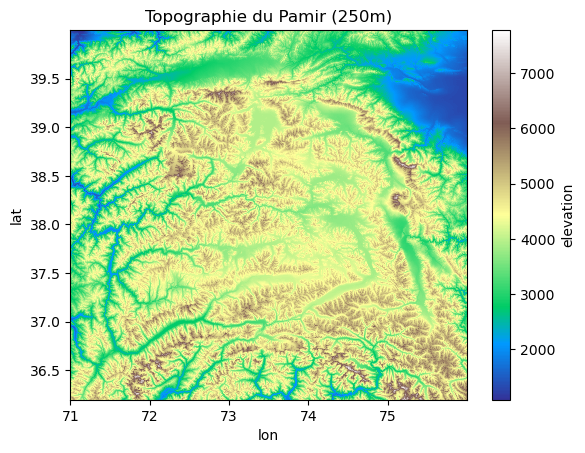

In [3]:
## ouverture d'une topo a 250m 
ds_topo_HR = xr.open_dataset("/bettik/PROJECTS/pr-regional-climate/mougina/gmted_topo_pamir.nc")
topo_HR = ds_topo_HR['elevation']

# Pamir : lon 68-76°E, lat 36-42°N
lon_min, lon_max =  71, 76
lat_min, lat_max = 36.19467, 40
vrai_topo_pamir = topo_HR.sel(
    lon=slice(lon_min, lon_max),
    lat=slice(lat_max, lat_min)  # lat décroissant dans ce fichier
)

if vrai_topo_pamir.sizes['lat'] == 0:
    vrai_topo_pamir = topo_HR.sel(
        lon=slice(lon_min, lon_max),
        lat=slice(lat_min, lat_max)
    )

print("Dimensions :", vrai_topo_pamir.shape)
print("Min :", float(vrai_topo_pamir.min()))
print("Max :", float(vrai_topo_pamir.max()))

vrai_topo_pamir.plot(cmap='terrain')
plt.title("Topographie du Pamir (250m)")
plt.show()

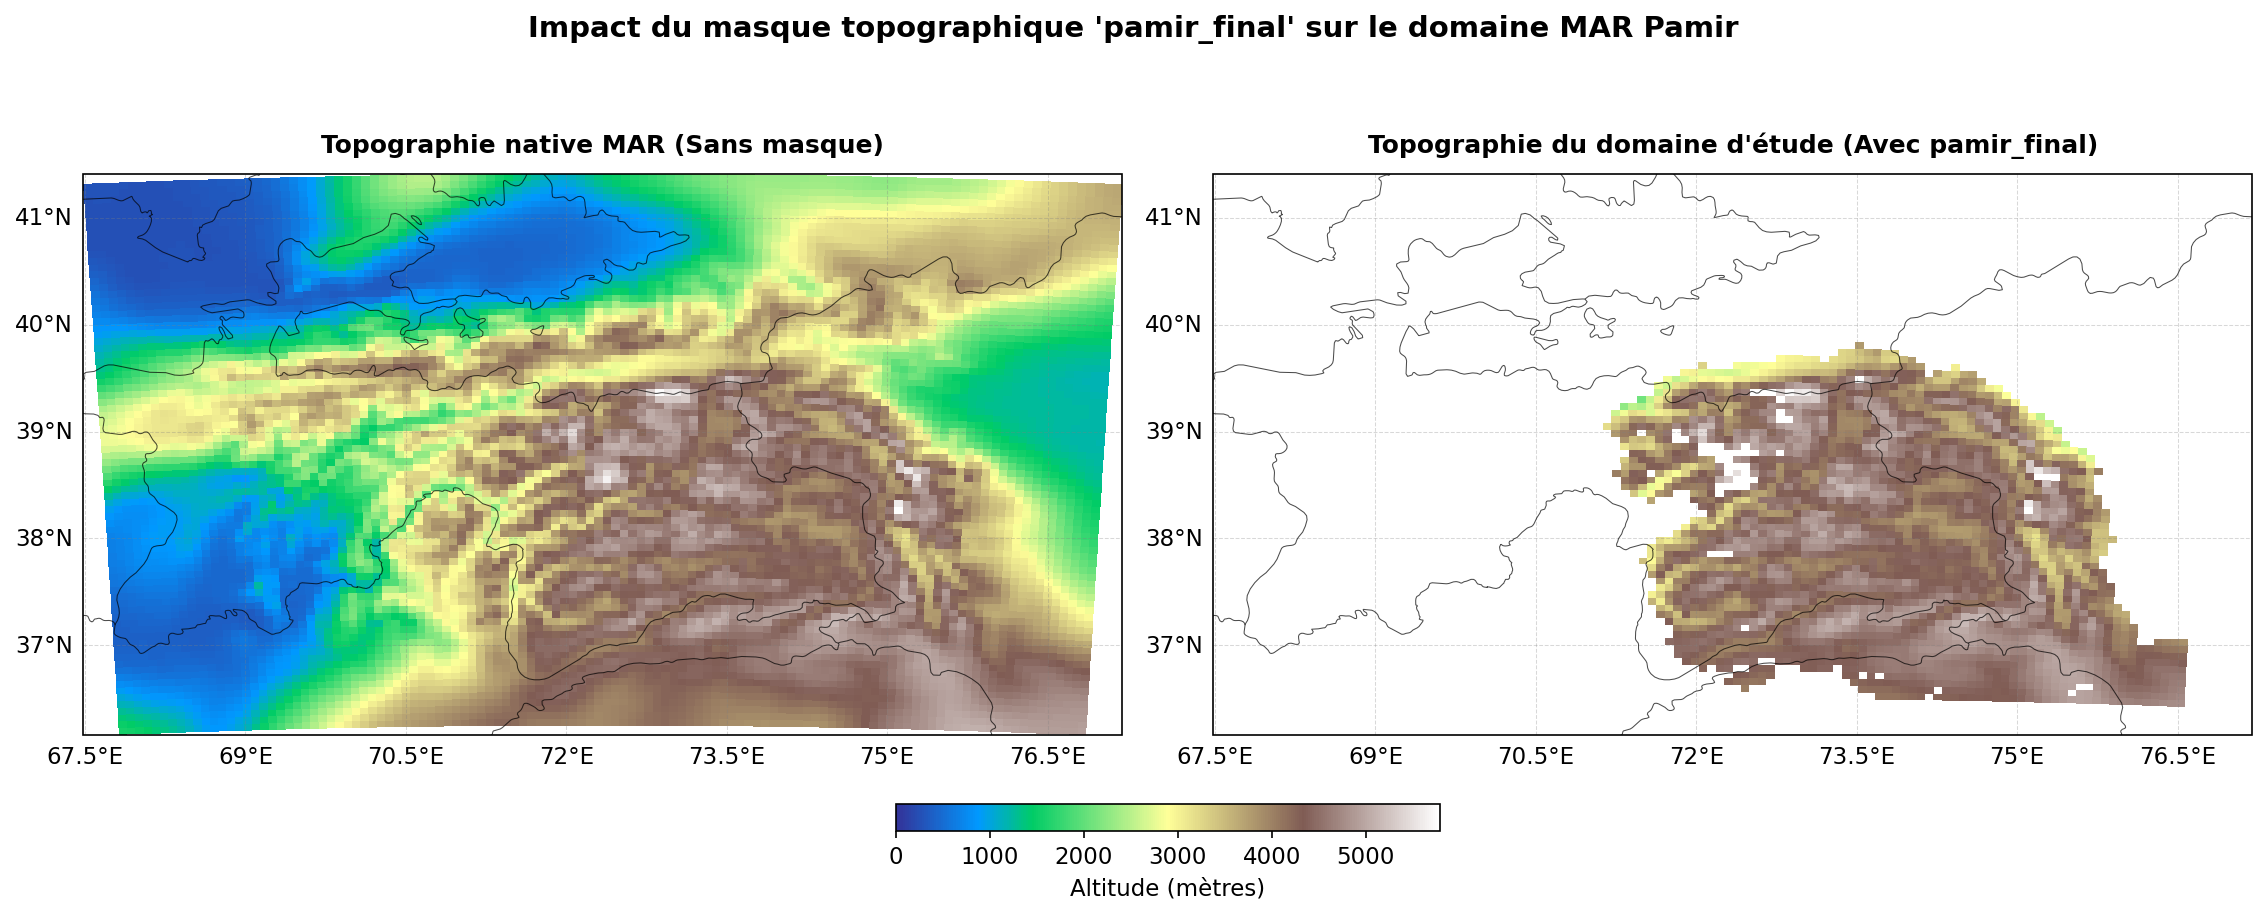

In [4]:
# topo mar
ds_grid_pamir = xr.open_dataset("/bettik/PROJECTS/pr-regional-climate/mougina/grille_MAR_Pamir/NST.2014.01.01.00.GRi.nc")
lon_pamir = np.array(ds_grid_pamir.LON)
lat_pamir = np.array(ds_grid_pamir.LAT)
H_pamir = np.array(ds_grid_pamir.SH)
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.titlesize': 12,
    'figure.dpi': 150,
})

fig, axs = plt.subplots(1, 2, figsize=(15, 6), subplot_kw={'projection': ccrs.PlateCarree()}, constrained_layout=True)
vmin_topo  = 0

vmin_topo = 0
vmax_topo = np.nanmax(H_pamir)  

ax_raw = axs[0]
im1 = ax_raw.pcolormesh(lon_pamir, lat_pamir, H_pamir, cmap='terrain', 
                        vmin=vmin_topo, vmax=vmax_topo, transform=ccrs.PlateCarree())
ax_raw.set_title("Topographie native MAR (Sans masque)", fontweight='bold', pad=10)

ax_mask = axs[1]
H_pamir_masquee = np.where(pamir_final, H_pamir, np.nan)
im2 = ax_mask.pcolormesh(lon_pamir, lat_pamir, H_pamir_masquee, cmap='terrain', 
                        vmin=vmin_topo, vmax=vmax_topo, transform=ccrs.PlateCarree())
ax_mask.set_title("Topographie du domaine d'étude (Avec pamir_final)", fontweight='bold', pad=10)

for ax in axs:


    ax.add_feature(cfeature.BORDERS, linestyle='-', linewidth=0.5, alpha=0.7, zorder=3)
    ax.coastlines(linewidth=0.6, zorder=3)
    
    gl = ax.gridlines(draw_labels=True, color='gray', alpha=0.3, linewidth=0.5, linestyle='--')
    gl.top_labels = gl.right_labels = False

cbar = fig.colorbar(im1, ax=axs, location='bottom', fraction=0.04, pad=0.05, shrink=0.4)
cbar.set_label('Altitude (mètres)', fontsize=11)

fig.suptitle("Impact du masque topographique 'pamir_final' sur le domaine MAR Pamir", size=14, fontweight='bold')

plt.show()

In [5]:
print(f"Altitude max native : {np.nanmax(H_pamir):.0f} m")
print(f"Altitude max masquée : {np.nanmax(H_pamir_masquee):.0f} m")

Altitude max native : 5785 m
Altitude max masquée : 5760 m


In [6]:
res_mar_lon = float(ds_grid.LON[0, 1] - ds_grid.LON[0, 0])
res_mar_lat = float(ds_grid.LAT[1, 0] - ds_grid.LAT[0, 0])
res_topo = float(topo_HR.lon[1] - topo_HR.lon[0])

facteur_lon = round(abs(res_mar_lon) / res_topo) 
facteur_lat = round(abs(res_mar_lat) / res_topo) 

sigma_topo = topo_HR.coarsen(
    lon=facteur_lon,
    lat=facteur_lat,
    boundary='trim'
).std()

lon_mar_1d = ds_grid.LON[0, :] 
lat_mar_1d = ds_grid.LAT[:, 0]  

sigma_on_mar = sigma_topo.interp(
    lon=lon_mar_1d,
    lat=lat_mar_1d,
    method='nearest'
)

print("Shape:", sigma_on_mar.shape)
print("Min:", float(sigma_on_mar.min()))
print("Max:", float(sigma_on_mar.max()))

Shape: (82, 116)
Min: 0.0
Max: 948.188955115763


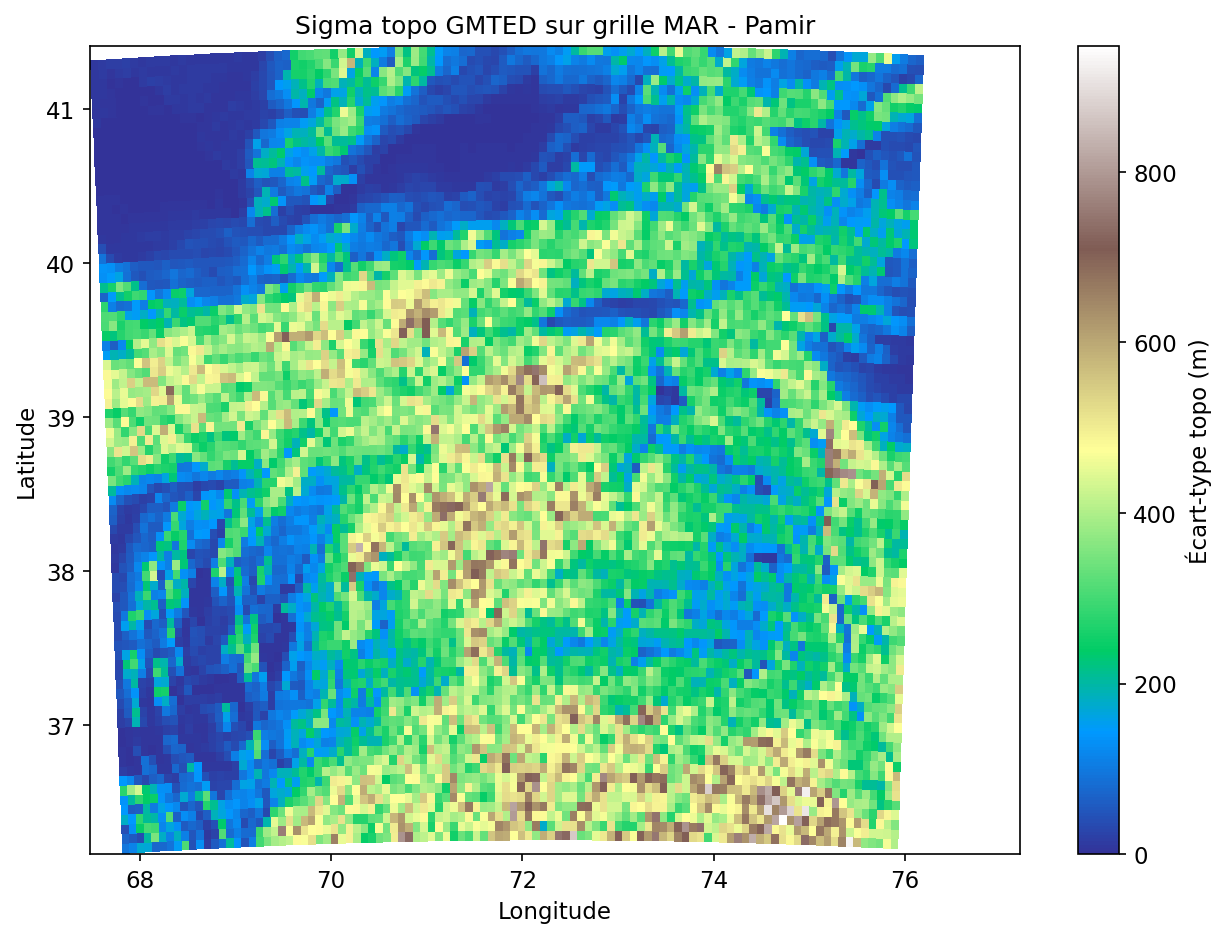

In [7]:
# ecart type 
fig, ax = plt.subplots(figsize=(10, 7))

p = ax.pcolormesh(
    ds_grid.LON.values,
    ds_grid.LAT.values,
    sigma_on_mar.values,
    cmap='terrain'
)
plt.colorbar(p, ax=ax, label='Écart-type topo (m)')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.title("Sigma topo GMTED sur grille MAR - Pamir")
plt.show()

In [8]:
## calcul de la densite moyenne plutot que sup 
def calc_rho_mean(ds_rho, SD):
    RO1 = ds_rho['RO1'].values  # numpy direct
    outlay = ds_rho['OUTLAY'].values
    SD_np = SD.values if hasattr(SD, 'values') else SD
    
    levels = np.array([0, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0, 2.0, 3.0, 5.0, 10.0, 15.0])
    
    result = np.zeros(RO1.shape[0:1] + RO1.shape[2:])  # (TIME, Y, X)
    
    for t in range(RO1.shape[0]):
        ro1_t = RO1[t]  # (OUTLAY, Y, X)
        sd_t  = SD_np[t] if SD_np.ndim == 3 else SD_np
        
        weights = np.zeros_like(ro1_t)
        for k in range(len(levels)-1):
            dz = np.minimum(levels[k+1], sd_t) - levels[k]
            dz = np.clip(dz, 0, None)
            weights[k] = dz
        
        total_w = weights.sum(axis=0)
        total_w[total_w == 0] = 1e-10
        result[t] = (ro1_t * weights).sum(axis=0) / total_w
    
    return xr.DataArray(result, dims=['time', 'Y', 'X'], coords={'time': ds_rho['TIME'].values})

In [9]:
z0g = 0.01         
rho_new = 50.0     ## les donnees so nt celle utilise dans l'article de Lalande et al. 2023
m = 1.0
beta = 3*10**-6
n = 3.0


In [10]:
years = [2016, 2017, 2018,2019,2020,2021]
lieu = "Pamir"
lat1, lat2, lon1, lon2 = 37.5, 40, 71, 76  ### coordonnees de base 36.19467

### 1 ere ouverture obs v4

--- Année 2017 (Avant Interpolation) ---
Max neige Hiver brut : 100.00%
Max neige Printemps brut : 100.00%
--- Année 2018 (Avant Interpolation) ---
Max neige Hiver brut : 100.00%
Max neige Printemps brut : 100.00%
--- Année 2019 (Avant Interpolation) ---
Max neige Hiver brut : 100.00%
Max neige Printemps brut : 100.00%
--- Année 2020 (Avant Interpolation) ---
Max neige Hiver brut : 100.00%
Max neige Printemps brut : 100.00%
--- Année 2021 (Avant Interpolation) ---
Max neige Hiver brut : 100.00%
Max neige Printemps brut : 100.00%


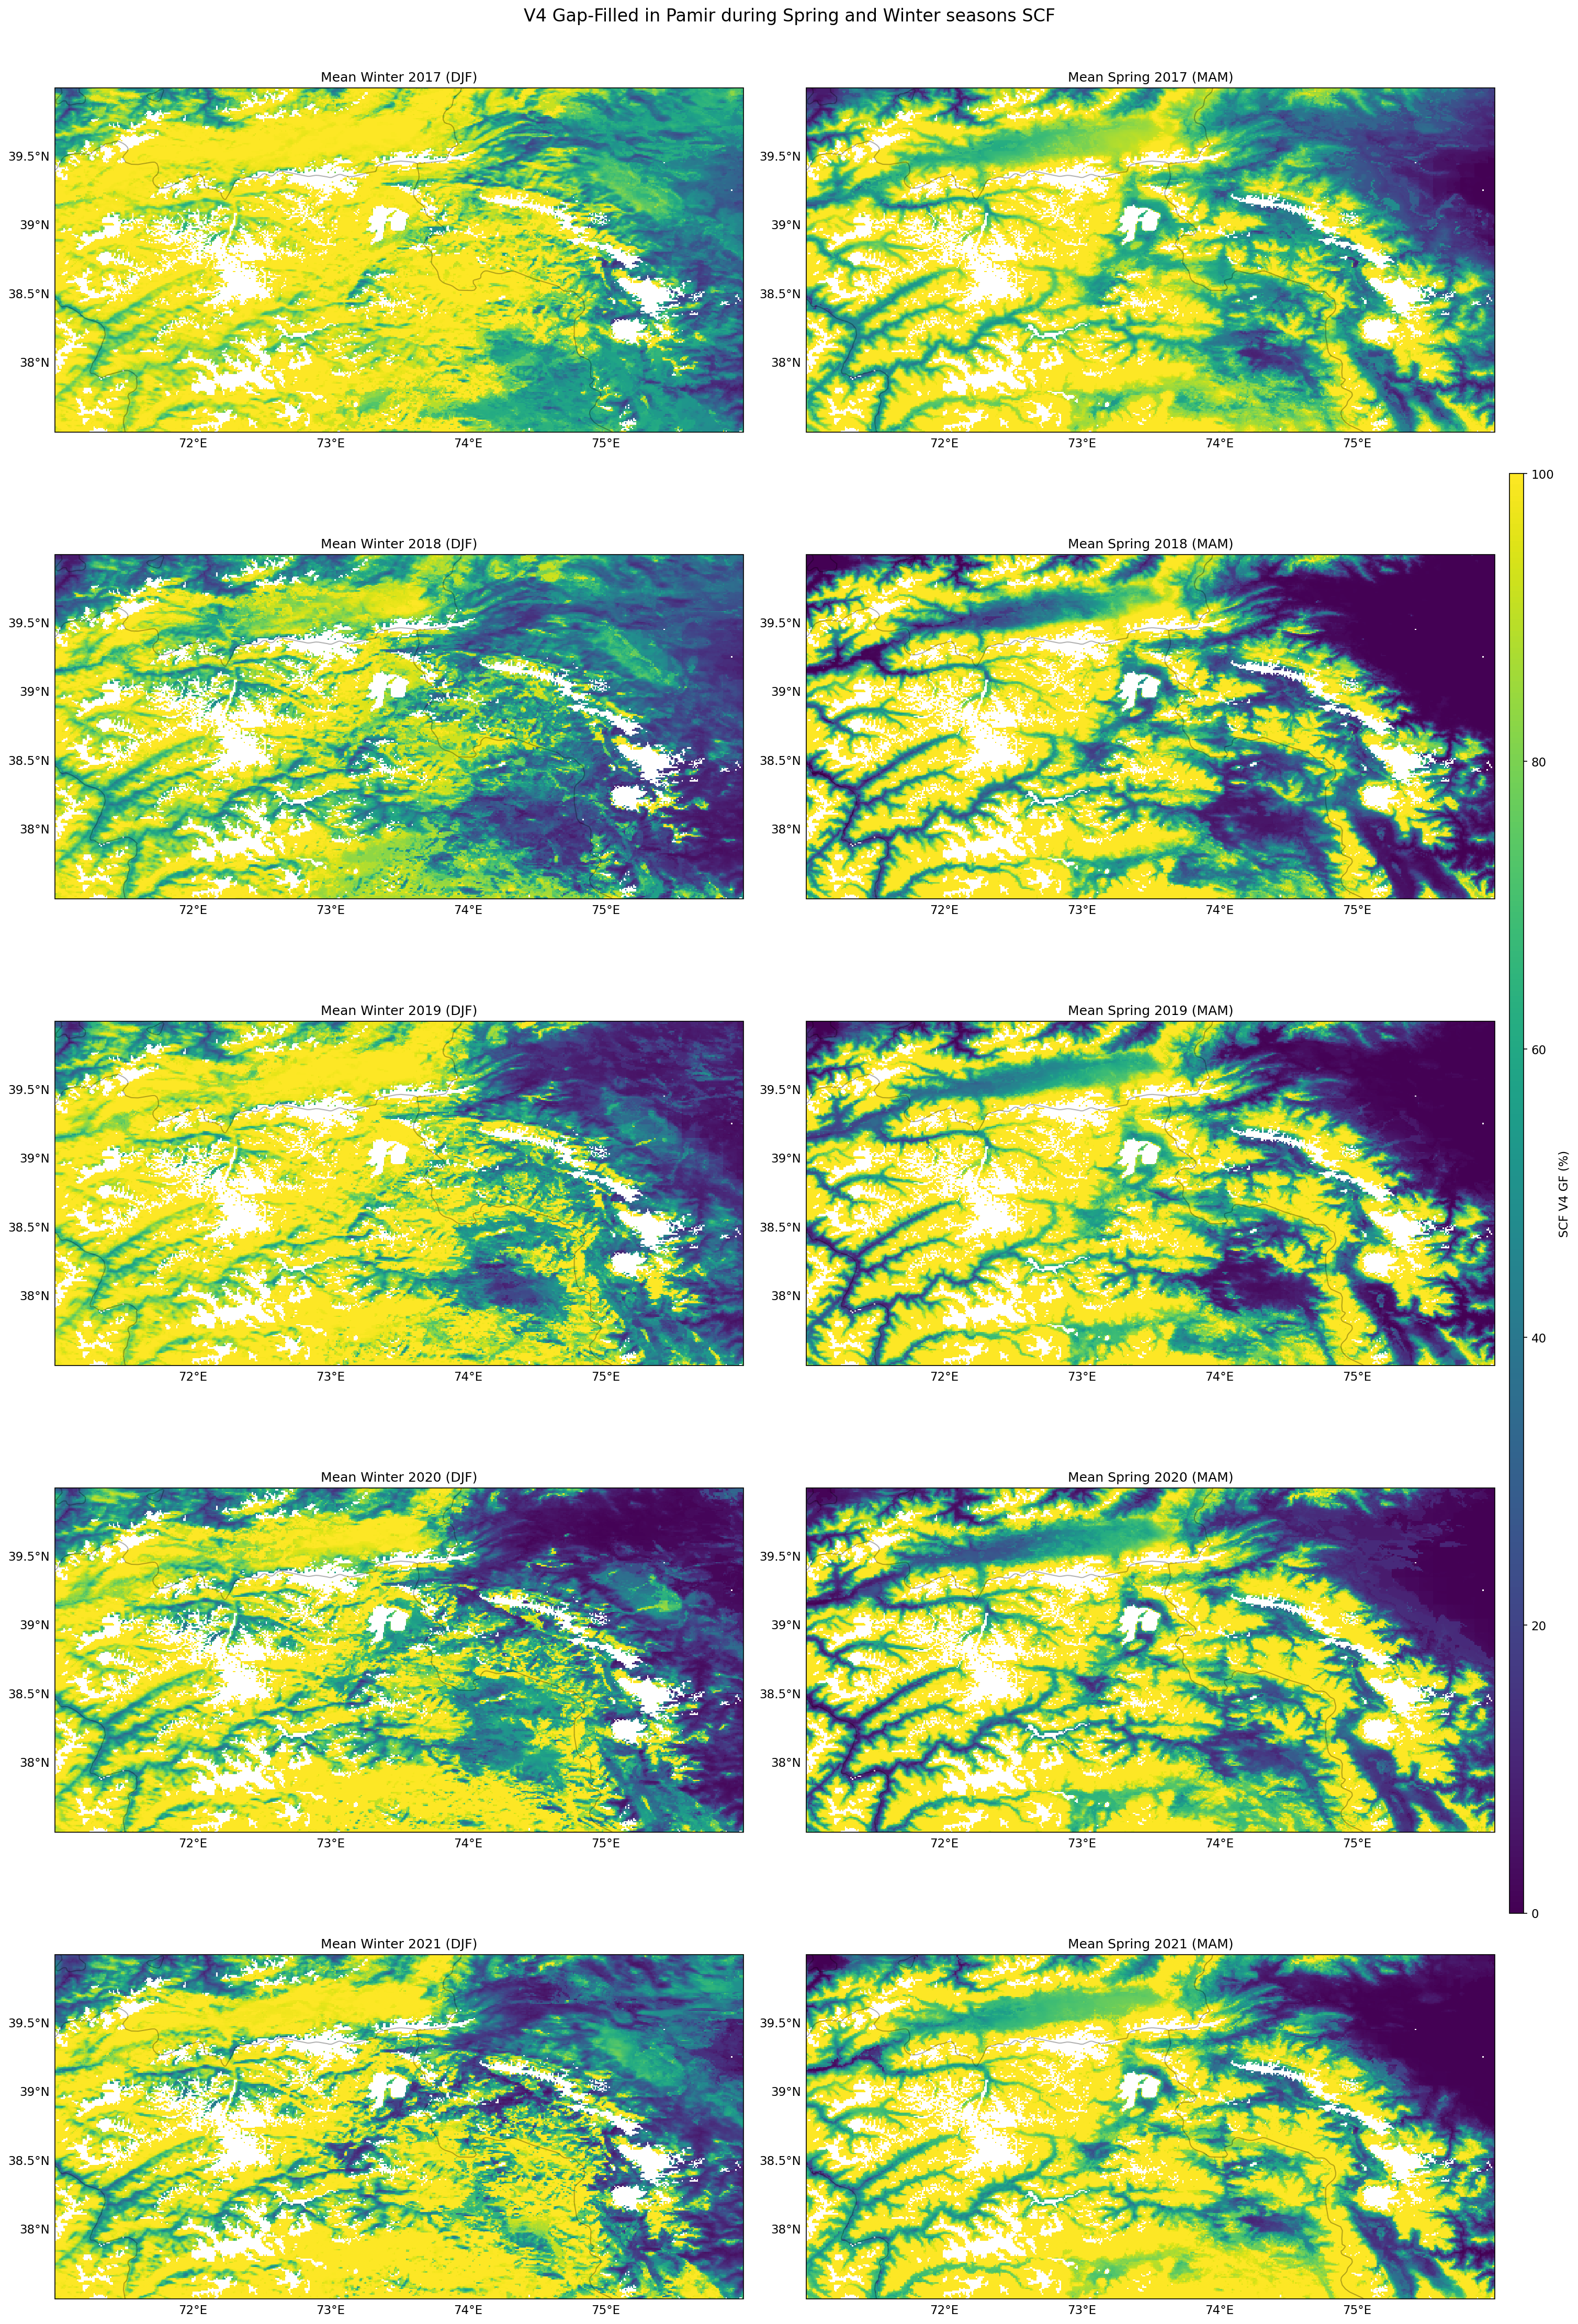

In [30]:
list_v4 = []
for yr in years:
    path = f"/bettik/PROJECTS/pr-regional-climate/mougina/data_v4_GF_pamir/SCFG_PAMIR_{yr}_V4GF.nc"
    ds_v_raw = xr.open_dataset(path, decode_cf=False)
    
    for v in ds_v_raw.variables:
        if 'dtype' in ds_v_raw[v].attrs: 
            del ds_v_raw[v].attrs['dtype']
            
    ds_v = xr.decode_cf(ds_v_raw)
    
    scfg_cleaned = ds_v['scfg'].where((ds_v['scfg'] >= 0) & (ds_v['scfg'] <= 100), np.nan)
    list_v4.append(scfg_cleaned)
    
all_v4 = xr.concat(list_v4, dim='time')

time_pd_v4 = all_v4.time.to_index()
season_labels = [get_season(t) for t in time_pd_v4]
all_v4 = all_v4.assign_coords(season=('time', season_labels))

years_to_plot = [2017, 2018, 2019,2020,2021]
n_rows = len(years_to_plot)

fig, axs = plt.subplots(n_rows, 2, figsize=(20, 30), 
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         constrained_layout=True)

for i, yr in enumerate(years_to_plot):
    ax = axs[i] if n_rows > 1 else axs
    
    target_spring = f"{yr}_MAM"
    target_winter = f"{yr}_DJF"
    spring_v4 = all_v4.where(all_v4.season == target_spring, drop=True).mean(dim='time')
    winter_v4 = all_v4.where(all_v4.season == target_winter, drop=True).mean(dim='time')

    print(f"--- Année {yr} (Avant Interpolation) ---")
    print(f"Max neige Hiver brut : {np.nanmax(winter_v4.values):.2f}%")
    print(f"Max neige Printemps brut : {np.nanmax(spring_v4.values):.2f}%")

    im2 = ax[0].pcolormesh(ds_v.lon, ds_v.lat, winter_v4, cmap='viridis', vmin=0, vmax=100, transform=ccrs.PlateCarree())
    im1 = ax[1].pcolormesh(ds_v.lon, ds_v.lat, spring_v4, cmap='viridis', vmin=0, vmax=90, transform=ccrs.PlateCarree())

    for sub_ax, title in zip([ax[0], ax[1]], [f"Mean Winter {yr} (DJF)", f"Mean Spring {yr} (MAM)"]):
        sub_ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
        sub_ax.add_feature(cfeature.BORDERS, linestyle='-', alpha=0.3)
        sub_ax.coastlines()
        sub_ax.set_title(title)
        
        gl = sub_ax.gridlines(draw_labels=True, color='gray', alpha=0.5, linewidth=0)
        gl.top_labels = False   
        gl.right_labels = False 
        gl.bottom_labels = True 

cbar = fig.colorbar(im2, ax=axs, label='SCF V4 GF (%)', fraction=0.01, aspect=100, pad=0.01)
plt.suptitle(f"V4 Gap-Filled in {lieu} during Spring and Winter seasons SCF", size=16)
#plt.savefig('/home/mougina/mes_analyses/carte_SCF_SCD/carte_v4_SCF_formuleNY07.png', dpi=100)
plt.show()

### Comparaison MAR vs  V4 avec un seuil de SD sur MAR 

In [12]:
seuil= 50
seuils_MAR = [0.01, 0.1, 0.5]
list_mar_raw = []
list_v4 = []
for i, yr in enumerate(years):
    ds_m = xr.open_dataset(f"/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRp/spin2/work/daily/SHSN3_daymean_MARv3.14_ER5_spin2_GRp_{yr}.nc").isel(SECTOR=1)
    ds_m = ds_m.rename({'TIME': 'time'})
    list_mar_raw.append(ds_m['SHSN3'])
    ds_v_raw = xr.open_dataset(f"/bettik/PROJECTS/pr-regional-climate/mougina/data_v4_GF_pamir/SCFG_PAMIR_{yr}_V4GF.nc", decode_cf=False)
    for v in ds_v_raw.variables:
        if 'dtype' in ds_v_raw[v].attrs:
            del ds_v_raw[v].attrs['dtype']
    ds_v = xr.decode_cf(ds_v_raw)
    ds_v['scfg'] = ds_v['scfg'].where((ds_v['scfg'] >= 0) & (ds_v['scfg'] <= 100), np.nan)
    v4_bin_full = (ds_v['scfg'] > seuil).astype(float) * 100
    v4_bin_regrid = v4_bin_full.interp(lon=ds_grid.LON, lat=ds_grid.LAT, method="linear", kwargs={'fill_value': np.nan})
    list_v4.append(v4_bin_regrid)
all_mar_raw = xr.concat(list_mar_raw, dim='time')
all_v4 = xr.concat(list_v4, dim='time')
all_mar_raw = all_mar_raw.sel(time=all_v4.time, method="nearest")
time_pd_v4 = all_v4.time.to_index()
season_labels = [get_season(t) for t in time_pd_v4]
all_v4 = all_v4.assign_coords(season=('time', season_labels))
all_mar_raw = all_mar_raw.assign_coords(season=('time', season_labels))
years_to_plot = [yr for yr in years if yr != 2016]
target_winters = [f"{yr}_DJF" for yr in years_to_plot]
winter_v4_clime = all_v4.where(all_v4.season.isin(target_winters), drop=True).mean(dim='time')
winter_v4_clime = winter_v4_clime.rename({'y': 'Y', 'x': 'X'})
rows = []
for seuilMAR in seuils_MAR:
    all_mar_bin = (all_mar_raw > seuilMAR).astype(float) * 100
    winter_mar = all_mar_bin.where(all_mar_bin.season.isin(target_winters), drop=True).mean(dim='time')
    n_days_winter = len(all_v4.where(all_v4.season.isin(target_winters), drop=True).time) / len(years_to_plot)
    scd_mar_jours = winter_mar * n_days_winter / 100
    diff_winter_vals = (winter_mar.values - winter_v4_clime.values) * n_days_winter / 100
    diff_winter = xr.DataArray(diff_winter_vals, dims=('Y', 'X'))
    titre_ligne = f"Seuil MAR = {seuilMAR}m"
    rows.append((titre_ligne, scd_mar_jours, diff_winter))   # <-- LIGNE MANQUANTE AJOUTÉE

print("rows length:", len(rows))



rows length: 3


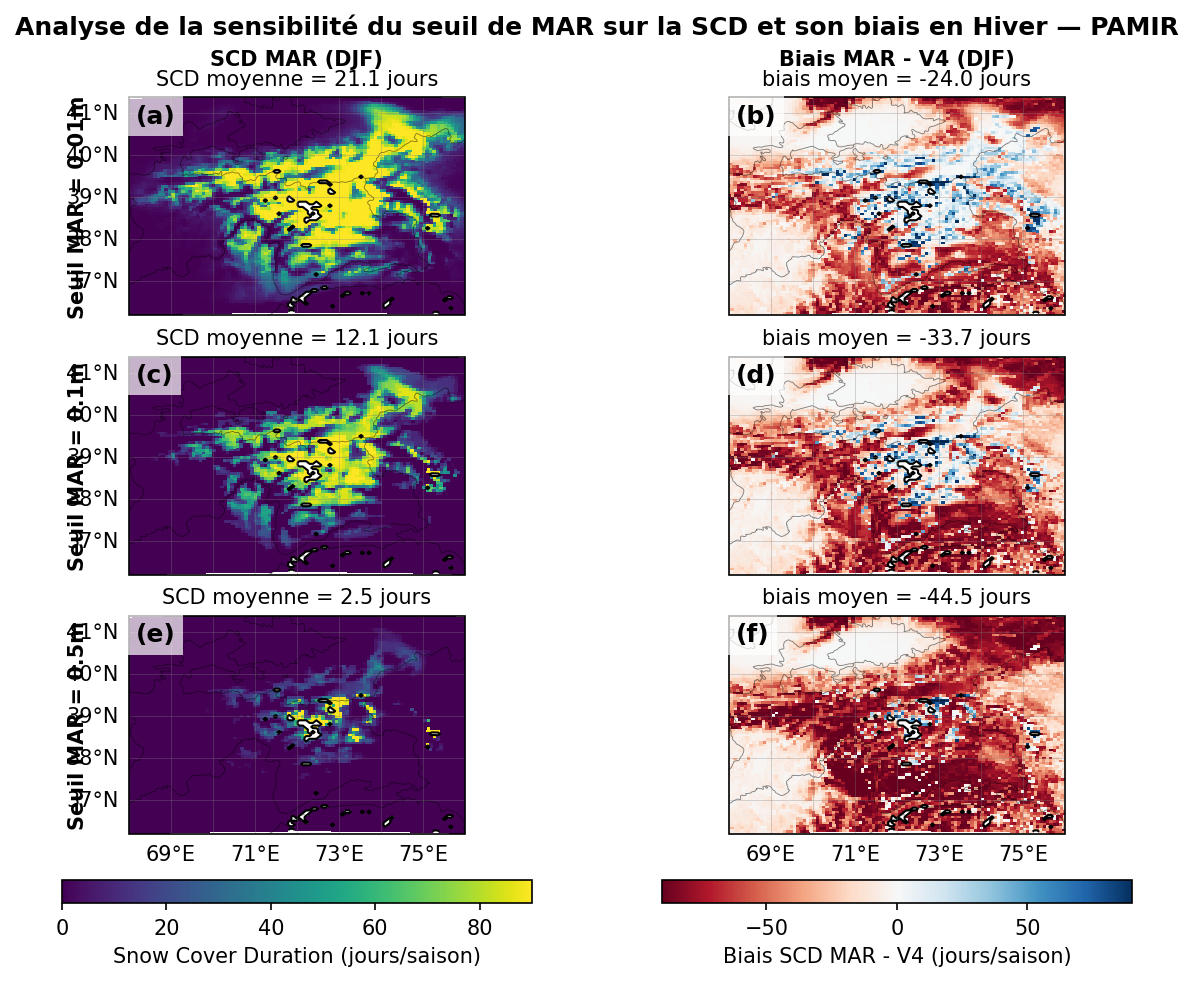

In [13]:



plt.rcParams.update({
    'font.family':     'sans-serif',
    'font.sans-serif': ['Liberation Sans', 'Nimbus Sans', 'Arial', 'DejaVu Sans'],
    'font.size':       10,
    'axes.titlesize':  11,
    'figure.dpi':      150,
})

fig, axs = plt.subplots(3, 2, figsize=(8, 6.2),
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         constrained_layout=True)

grey_mask_pamir = np.where(pamir, np.nan, 0.2)
im_scd = None
im_diff = None
for i, (titre, scd_mar, diff_w) in enumerate(rows):
    for j, (ax, data_plot, cmap_name, v_min, v_max, label_titre) in enumerate([
        (axs[i,0], scd_mar.where(pamir_ice==True), 'viridis', 0, 90, "SCD MAR"),
        (axs[i,1], diff_w.where(pamir_ice==True), 'RdBu', -90, 90, "Biais MAR - V4")
    ]):
        idx = i * 2 + j
        lettre = f"({chr(97 + idx)})"
        ax.pcolormesh(ds_grid.LON, ds_grid.LAT, grey_mask_pamir,
                      cmap='Greys', vmin=0, vmax=1, transform=ccrs.PlateCarree())

        im = ax.pcolormesh(ds_grid.LON, ds_grid.LAT, data_plot,
                           cmap=cmap_name, vmin=v_min, vmax=v_max,
                           transform=ccrs.PlateCarree())
        if j == 0 and im_scd is None:
            im_scd = im
        if j == 1 and im_diff is None:
            im_diff = im
        ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
        ax.coastlines(linewidth=0.6)
        ax.add_feature(cfeature.BORDERS, linewidth=0.4, alpha=0.5)
        ax.contour(lon_pamir, lat_pamir, pamir_ice, levels=[0.5], colors='k', linewidths=1.0)

        if i == 0:
            column_name = f"{label_titre} (DJF)"
            ax.text(0.5, 1.13, column_name, transform=ax.transAxes,
                    fontsize=10, ha='center', va='bottom', fontweight='bold')

        if j == 0:
            ax.text(-0.12, 0.5, titre, transform=ax.transAxes,
                    fontsize=10, ha='right', va='center', rotation=90, fontweight='bold')

        data_mean = float(np.nanmean(data_plot))
        if j == 0:
            ax.set_title(f"SCD moyenne = {data_mean:.1f} jours", fontsize=10)
        else:
            ax.set_title(f"biais moyen = {data_mean:.1f} jours", fontsize=10)

        gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5)
        gl.top_labels = False
        gl.right_labels = False
        gl.left_labels = False
        gl.bottom_labels = False
        if j == 0:
            gl.left_labels = True
        if i == 2:
            gl.bottom_labels = True
        ax.text(0.02, 0.97, lettre, transform=ax.transAxes,
                    fontsize=12, fontweight='bold', va='top',
                    bbox=dict(fc='white', ec='none', alpha=0.7))

cbar_scd = fig.colorbar(im_scd, ax=axs[:, 0], orientation='horizontal',
                         location='bottom', fraction=0.04, pad=0.02, shrink=0.8)
cbar_scd.set_label('Snow Cover Duration (jours/saison)', fontsize=10)

cbar_diff = fig.colorbar(im_diff, ax=axs[:, 1], orientation='horizontal',
                          location='bottom', fraction=0.04, pad=0.02, shrink=0.8)
cbar_diff.set_label('Biais SCD MAR - V4 (jours/saison)', fontsize=10)

plt.suptitle(f"Analyse de la sensibilité du seuil de MAR sur la SCD et son biais en Hiver — PAMIR", fontsize=12, fontweight='bold', y=1.03)
plt.savefig('/home/mougina/mes_analyses_neige/carte_seuils_MAR_hiver_pamir.png', dpi=100, bbox_inches='tight')
plt.show()

### Biais MAR avec formule LA23

In [11]:
list_mar= []
list_v4 = []
topo_numpy = sigma_on_mar.values
for yr in years:
    ds_m = xr.open_dataset(f"/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRp/spin2/work/daily/SHSN3_daymean_MARv3.14_ER5_spin2_GRp_{yr}.nc").isel(SECTOR=1).rename({'TIME': 'time'})
    ds_rho = xr.open_dataset(f"/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRp/spin2/work/daily/RO1_daymean_MARv3.14_ER5_spin2_GRp_{yr}.nc",drop_variables=['TIME_bnds', 'OUTLAY_bnds']
)
    SD = ds_m['SHSN3']
    rho_snow = calc_rho_mean(ds_rho, SD).load()
    ds_rho.close()
    denominateur = (2.5 * z0g * ((rho_snow / rho_new) ** m)) + (beta * topo_numpy * ((rho_snow / rho_new) ** n))
    denominateur_safe = denominateur.where(denominateur > 0, other=1e-10)
    scf_mar = xr.where(SD == 0, 0, np.tanh(SD / denominateur_safe) * 100)
    list_mar.append(scf_mar)
    ds_v_raw = xr.open_dataset(f"/bettik/PROJECTS/pr-regional-climate/mougina/data_v4_GF_pamir/SCFG_PAMIR_{yr}_V4GF.nc", decode_cf=False)
    for v in ds_v_raw.variables:
        if 'dtype' in ds_v_raw[v].attrs:
            del ds_v_raw[v].attrs['dtype']
    ds_v = xr.decode_cf(ds_v_raw)
    ds_v['scfg'] = ds_v['scfg'].where((ds_v['scfg'] >= 0) & (ds_v['scfg'] <= 100), np.nan)
    v4_bin_regrid = ds_v['scfg'].interp(
        lon=ds_grid.LON, lat=ds_grid.LAT,
        method="linear", kwargs={'fill_value': np.nan}
    ).load()
    ds_v_raw.close()
    list_v4.append(v4_bin_regrid)
    print(f"{yr} ok")

2016 ok
2017 ok
2018 ok
2019 ok
2020 ok
2021 ok


In [12]:
import matplotlib.patheffects as path_effects

In [13]:
lat1, lat2, lon1, lon2 = 37.5, 40, 71, 76

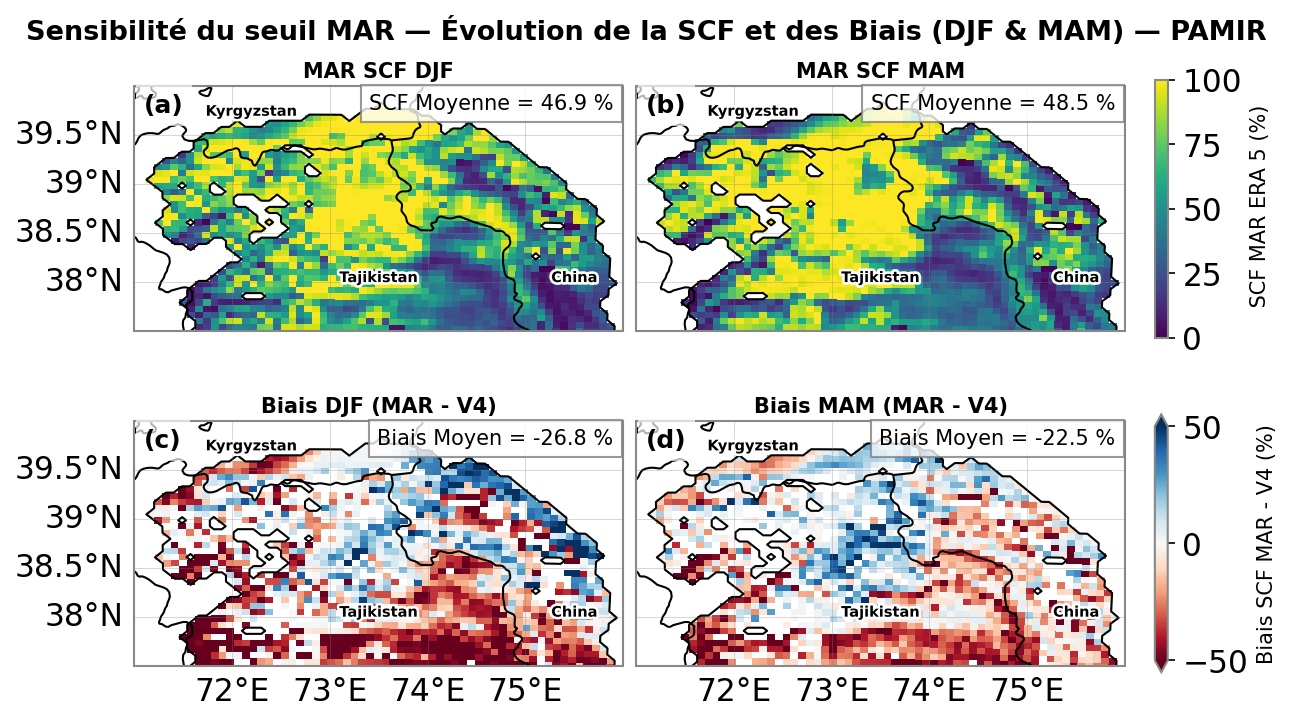

In [35]:

all_mar = xr.concat(list_mar, dim='time')
all_v4 = xr.concat(list_v4, dim='time')
all_mar = all_mar.sel(time=all_v4.time, method="nearest")

time_pd_v4 = all_v4.time.to_index()
season_labels = [get_season(t) for t in time_pd_v4]
all_v4 = all_v4.assign_coords(season=('time', season_labels))
all_mar = all_mar.assign_coords(season=('time', season_labels))

years_to_plot  = [yr for yr in years if yr != 2016]
target_winters = [f"{yr}_DJF" for yr in years_to_plot]
target_springs = [f"{yr}_MAM" for yr in years_to_plot]

winter_v4_clime  = all_v4.where(all_v4.season.isin(target_winters), drop=True).mean(dim='time')
spring_v4_clime  = all_v4.where(all_v4.season.isin(target_springs), drop=True).mean(dim='time')
winter_mar_clime = all_mar.where(all_mar.season.isin(target_winters), drop=True).mean(dim='time')
spring_mar_clime = all_mar.where(all_mar.season.isin(target_springs), drop=True).mean(dim='time')

winter_mar_np = winter_mar_clime.values
winter_v4_np  = winter_v4_clime.values
spring_mar_np = spring_mar_clime.values
spring_v4_np  = spring_v4_clime.values

diff_winter_np = winter_mar_np - winter_v4_np
diff_spring_np = spring_mar_np - spring_v4_np

mask_numpy = (pamir_final == True)

winter_mar_masked = np.where(mask_numpy, winter_mar_np, np.nan)
spring_mar_masked = np.where(mask_numpy, spring_mar_np, np.nan)

winter_bias_masked = np.where(mask_numpy, diff_winter_np, np.nan)
spring_bias_masked = np.where(mask_numpy, diff_spring_np, np.nan)

fig, axs = plt.subplots(2, 2, figsize=(8.5, 4.5),
                         subplot_kw={'projection': ccrs.PlateCarree()},
                         constrained_layout=True)

im_scf = None
im_diff = None

plot_structure = [
    ((0, 0), winter_mar_masked, "MAR SCF DJF", "scf"),
    ((0, 1), spring_mar_masked, "MAR SCF MAM", "scf"),
    ((1, 0), winter_bias_masked, "Biais DJF (MAR - V4)", "bias"),
    ((1, 1), spring_bias_masked, "Biais MAM (MAR - V4)", "bias")
]

for idx, ((row, col), data_plot, label_titre, plot_type) in enumerate(plot_structure):
    ax = axs[row, col]
    lettre = f"({chr(97 + idx)})"
    
    # Configuration des colormaps selon la ligne
    if plot_type == "scf":
        im = ax.pcolormesh(ds_grid.LON.values, ds_grid.LAT.values, data_plot,
                           cmap='viridis', vmin=0, vmax=100, transform=ccrs.PlateCarree())
        if im_scf is None: im_scf = im
        mean_val = float(np.nanmean(data_plot))
        texte_encadre1 = f"SCF Moyenne = {mean_val:.1f} %"
    
        ax.text(0.98, 0.97, texte_encadre1, transform=ax.transAxes,
                fontsize=10, va='top', ha='right', zorder=5,
                bbox=dict(facecolor='white', edgecolor='gray', alpha=0.8))
    else:
        im = ax.pcolormesh(ds_grid.LON.values, ds_grid.LAT.values, data_plot,
                           cmap='RdBu', vmin=-50, vmax=50, transform=ccrs.PlateCarree())
        if im_diff is None: im_diff = im
        mean_val = float(np.nanmean(data_plot))
        texte_encadre2 = f"Biais Moyen = {mean_val:.1f} %"
    
        ax.text(0.98, 0.97, texte_encadre2, transform=ax.transAxes,
                fontsize=10, va='top', ha='right', zorder=5,
                bbox=dict(facecolor='white', edgecolor='gray', alpha=0.8))
    # Configuration cartographique
    ax.set_extent([lon1, lon2, lat1, lat2], crs=ccrs.PlateCarree())
    ax.coastlines(linewidth=0.6)
    ax.add_feature(cfeature.BORDERS, linewidth=1, alpha=1)
    ax.contour(lon_pamir, lat_pamir, pamir_final, levels=[0.5], colors='k', linewidths=1.0)
    
    # Titre de la saison / variable
    ax.text(0.5, 1.02, label_titre, transform=ax.transAxes,
            fontsize=10, ha='center', va='bottom', fontweight='bold')
            

    
    t1 = ax.text(73.5, 38, 'Tajikistan', transform=ccrs.PlateCarree(), fontsize=7, color='k', weight='bold', ha='center')
    t2 = ax.text(72.2, 39.7, 'Kyrgyzstan', transform=ccrs.PlateCarree(), fontsize=7, color='k', weight='bold', ha='center')
    t3 = ax.text(75.5, 38.0, 'China', transform=ccrs.PlateCarree(), fontsize=7, color='k', weight='bold', ha='center')
    #t4 = ax.text(73.0, 37.0, 'Afghanistan', transform=ccrs.PlateCarree(), fontsize=7, color='k', weight='bold', ha='center')
    #t5 = ax.text(75.0, 36.4, 'Pakistan', transform=ccrs.PlateCarree(), fontsize=7, color='k', weight='bold', ha='center')

    contour_blanc = [path_effects.Stroke(linewidth=2.5, foreground='white'), path_effects.Normal()]

    for t in [t1, t2, t3]:
        t.set_path_effects(contour_blanc)
    
    gl = ax.gridlines(draw_labels=True, linewidth=0.3, color='gray', alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.left_labels = (col == 0)      
    gl.bottom_labels = (row == 1)    

    ax.text(0.02, 0.97, lettre, transform=ax.transAxes, fontsize=12,
            fontweight='bold', va='top', bbox=dict(fc='white', ec='none', alpha=0.7))

cbar_scf = fig.colorbar(im_scf, ax=axs[0, :], orientation='vertical',
                        location='right', fraction=0.04, pad=0.03, shrink=0.8)
cbar_scf.set_label(' SCF MAR ERA 5 (%)', fontsize=10)

cbar_bias = fig.colorbar(im_diff, ax=axs[1, :], orientation='vertical',
                         location='right', fraction=0.04, pad=0.03, shrink=0.8, extend='both')
cbar_bias.set_label('Biais SCF MAR - V4 (%)', fontsize=10)

plt.suptitle("Sensibilité du seuil MAR — Évolution de la SCF et des Biais (DJF & MAM) — PAMIR", 
             fontsize=13, fontweight='bold', y=1.04)
plt.savefig('/home/mougina/mes_analyses_neige/Biais_MAR_v4_LA23_pamir.png', dpi=100, bbox_inches='tight')
plt.show()

## Correction 

In [1]:
all_v4_renamed = all_v4.rename({'y': 'Y', 'x': 'X'})
all_v4_renamed = all_v4_renamed.assign_coords(Y=all_mar.Y, X=all_mar.X)
biais_pixel_mensuel = (all_mar.groupby('time.month').mean('time')- all_v4_renamed.groupby('time.month').mean('time'))

NameError: name 'all_v4' is not defined

In [41]:
## fonction ligne de neige modifie pamir
altitude = ds_grid['SH'].values  
def calculer_ligne_neige_journaliere(scf_mar, altitude, alps_ice, seuil=50, n_pixels=100):  ### le nombre de pixels et le seuils sont modifier ici 
    """
    Calcule la ligne de neige selon 3 critères :
    (i)  mean elevation des 10 plus hauts pixels SANS neige (SCF < seuil)
    (ii) mean elevation des 10 plus bas pixels AVEC neige (SCF >= seuil)
    (iii) moyenne de (i) et (ii) → ligne de neige
    """
    alt_flat = altitude[alps_ice]
    n_temps = scf_mar.sizes['time']
    
    critere_1 = np.full(n_temps, np.nan)  
    critere_2 = np.full(n_temps, np.nan)  
    critere_3 = np.full(n_temps, np.nan)   
    for t in range(n_temps):
        jour = scf_mar.isel(time=t).values
        scf_flat = jour[alps_ice]
        
        mask_valid = ~np.isnan(scf_flat)
        scf_v = scf_flat[mask_valid]
        alt_v = alt_flat[mask_valid]
        
        if len(scf_v) < 20:
            continue
        alt_avec_neige = alt_v[scf_v >= seuil]
        alt_sans_neige = alt_v[scf_v < seuil]
        
        if len(alt_avec_neige) < n_pixels or len(alt_sans_neige) < n_pixels:
            continue
        critere_1[t] = np.mean(np.sort(alt_sans_neige)[-n_pixels:])
        critere_2[t] = np.mean(np.sort(alt_avec_neige)[:n_pixels])

        critere_3[t] = (critere_1[t] + critere_2[t]) / 2
    return (
        xr.DataArray(critere_1, coords=[scf_mar.time], dims=['time']),
        xr.DataArray(critere_2, coords=[scf_mar.time], dims=['time']),
        xr.DataArray(critere_3, coords=[scf_mar.time], dims=['time'])
    )

In [42]:
### modification de la fonction par rapport aux alpes pour eviter de casser le kernel mais il s'agit bien de la correction mensuelle
def corriger_biais_pixel(all_mar, biais_pixel_mensuel):
    liste_corriges = []

    for m in range(1, 13):
        mar_jours = all_mar.where(all_mar['time.month'] == m, drop=True)
        n_jours = mar_jours.sizes['time']
        if n_jours == 0:
            continue

        m_prev = 12 if m == 1 else m - 1
        m_next = 1  if m == 12 else m + 1

        biais_prev = biais_pixel_mensuel.sel(month=m_prev)
        biais_curr = biais_pixel_mensuel.sel(month=m)
        biais_next = biais_pixel_mensuel.sel(month=m_next)

        pos = np.linspace(0, 1, n_jours) if n_jours > 1 else np.array([0.5])

        # poids vectorisés (1D, taille n_jours)
        alpha1 = np.where(pos < 0.5, pos * 2, 0.0)          # poids vers curr depuis prev
        alpha2 = np.where(pos >= 0.5, (pos - 0.5) * 2, 0.0)  # poids vers next depuis curr

        w_prev = np.where(pos < 0.5, 1 - alpha1, 0.0)
        w_curr = np.where(pos < 0.5, alpha1, 1 - alpha2)
        w_next = np.where(pos < 0.5, 0.0, alpha2)

        w_prev_da = xr.DataArray(w_prev, dims='time', coords={'time': mar_jours.time})
        w_curr_da = xr.DataArray(w_curr, dims='time', coords={'time': mar_jours.time})
        w_next_da = xr.DataArray(w_next, dims='time', coords={'time': mar_jours.time})

        biais_mois = (w_prev_da * biais_prev + w_curr_da * biais_curr + w_next_da * biais_next)

        jour_corrige = (mar_jours - biais_mois).clip(0, 100)
        liste_corriges.append(jour_corrige)

    return xr.concat(liste_corriges, dim='time').sortby('time')

In [43]:
### ouverture MAR sur cette periode
years = range(1950, 2025)  
list_ln3_brut_pamir = []
list_ln3_corr_pamir = []
list_scf_annuel_pamir = []
list_scf_mensuel_brut_pamir = []   
list_scf_mensuel_corr_pamir = []   

altitude_pamir = ds_grid['SH'].values  
topo_numpy = sigma_on_mar.values
for yr in years:
    ds_m = xr.open_dataset(
        f"/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRp/spin2/work/daily/SHSN3_daymean_MARv3.14_ER5_spin2_GRp_{yr}.nc"
    ).isel(SECTOR=1).rename({'TIME': 'time'})
    ds_rho = xr.open_dataset(
        f"/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/GRp/spin2/work/daily/RO1_daymean_MARv3.14_ER5_spin2_GRp_{yr}.nc",
        drop_variables=['TIME_bnds', 'OUTLAY_bnds']
    )
    SD = ds_m['SHSN3']
    rho_snow = calc_rho_mean(ds_rho, SD).load()
    
    denominateur = (2.5 * z0g * ((rho_snow / rho_new) ** m)) + \
                   (beta * topo_numpy * ((rho_snow / rho_new) ** n))
    denominateur_safe = denominateur.where(denominateur > 0, other=1e-10)
    scf_mar = xr.where(SD == 0, 0, np.tanh(SD / denominateur_safe) * 100)
    pamir_mask_da = xr.DataArray(pamir_final, dims=scf_mar.dims[1:])
    scf_mar = scf_mar.where(pamir_mask_da)
    
    scf_corr = corriger_biais_pixel(scf_mar, biais_pixel_mensuel)

    list_scf_annuel_pamir.append({
        'year': yr,
        'brut': float(np.nanmean(scf_mar.values)),
        'mensuel': float(np.nanmean(scf_corr.values)),
    })

    # --- AJOUT : moyenne spatiale (Y,X) -> série temporelle, puis resample mensuel ---
    scf_mar_spatial = scf_mar.mean(dim=['Y', 'X'], skipna=True)
    scf_corr_spatial = scf_corr.mean(dim=['Y', 'X'], skipna=True)
    list_scf_mensuel_brut_pamir.append(scf_mar_spatial.resample(time='1MS').mean().load())
    list_scf_mensuel_corr_pamir.append(scf_corr_spatial.resample(time='1MS').mean().load())
    
    _, _, ln3_brut = calculer_ligne_neige_journaliere(scf_mar,  altitude_pamir, pamir_final)
    _, _, ln3_corr = calculer_ligne_neige_journaliere(scf_corr, altitude_pamir, pamir_final)
    
    list_ln3_brut_pamir.append(ln3_brut.resample(time='1MS').median().load())
    list_ln3_corr_pamir.append(ln3_corr.resample(time='1MS').median().load())
    
    ds_m.close()
    ds_rho.close()
    del scf_mar, scf_corr, ds_m, ds_rho, rho_snow, SD, denominateur, denominateur_safe
    import gc
    gc.collect()

df_scf_pamir = pd.DataFrame(list_scf_annuel_pamir)
scf_mensuel_brut_pamir = xr.concat(list_scf_mensuel_brut_pamir, dim='time')   # <-- AJOUT
scf_mensuel_corr_pamir = xr.concat(list_scf_mensuel_corr_pamir, dim='time')   # <-- AJOUT

ligne_neige_brut_pamir = xr.concat(list_ln3_brut_pamir, dim='time')
ligne_neige_corr_pamir = xr.concat(list_ln3_corr_pamir, dim='time')

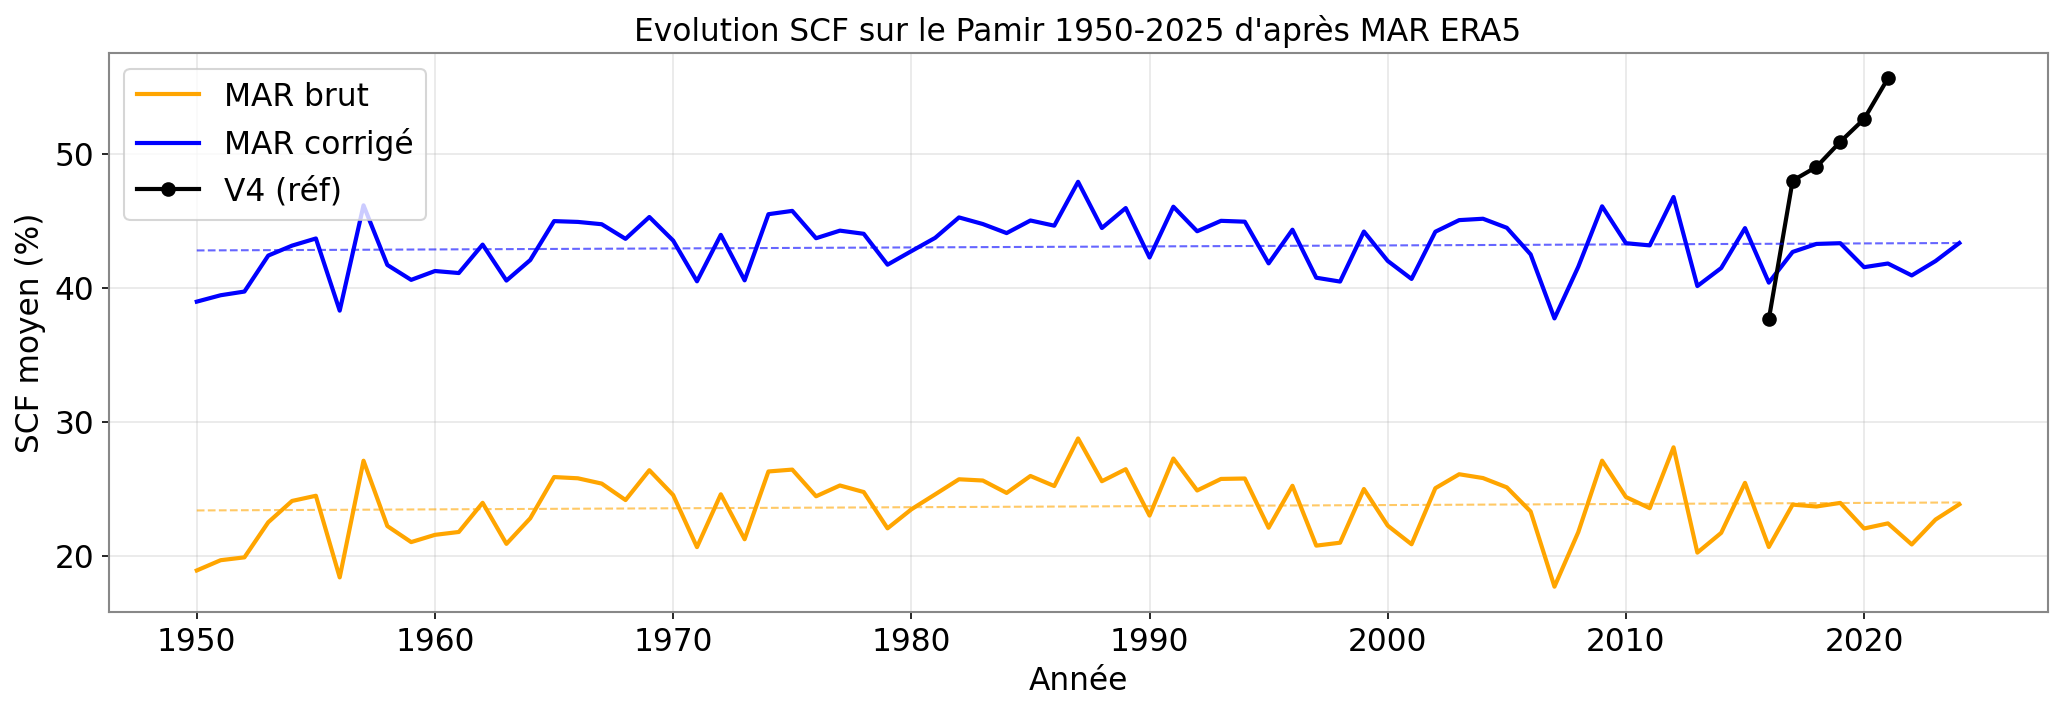

Tendance brut         : +0.0080 %/an  (soit +0.59% sur 74 ans)  | diff simple (dernier-premier) : +4.93%
Tendance corr         : +0.0075 %/an  (soit +0.55% sur 74 ans)  | diff simple (dernier-premier) : +4.37%


<Figure size 960x720 with 0 Axes>

In [58]:
### plot par annee de SCF permettant d'observer la correction
all_v4_renamed = all_v4.rename({'y': 'Y', 'x': 'X'}).assign_coords(Y=all_mar.Y, X=all_mar.X)
pamir_mask_da = xr.DataArray(pamir_final, dims=['Y', 'X'])

scf_v4_annuel = all_v4_renamed.where(pamir_mask_da).groupby('time.year').mean(dim=['time', 'Y', 'X'])
df_v4_pamir = pd.DataFrame({
    'year': scf_v4_annuel.year.values,
    'v4': scf_v4_annuel.values
})

# --- Plot ---
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(df_scf_pamir.year, df_scf_pamir.brut,    color='orange', label='MAR brut',    linewidth=2)
ax.plot(df_scf_pamir.year, df_scf_pamir.mensuel, color='blue',   label='MAR corrigé', linewidth=2)
ax.plot(df_v4_pamir.year,  df_v4_pamir.v4,       color='black',  label='V4 (réf)',    linewidth=2, marker='o')

tendances_pamir = {}
for col, color in [('brut', 'orange'), ('mensuel', 'blue')]:
    slope, intercept, r_value, p_value, std_err = stats.linregress(df_scf_pamir.year, df_scf_pamir[col])
    tendances_pamir[col] = slope
    fit = intercept + slope * df_scf_pamir.year
    ax.plot(df_scf_pamir.year, fit, color=color, linestyle='--', linewidth=1, alpha=0.6)

ax.set_ylabel('SCF moyen (%)')
ax.set_xlabel('Année')
ax.set_title("Evolution SCF sur le Pamir 1950-2025 d'après MAR ERA5")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig('/home/mougina/mes_analyses_neige/SCF_annuel_PAMIR.png', dpi=200, bbox_inches='tight')
n_annees = df_scf_pamir.year.iloc[-1] - df_scf_pamir.year.iloc[0]
for col, label in [('brut', 'brut'), ('mensuel', 'corr')]:
    print(f"Tendance {label:12s} : {tendances_pamir[col]:+.4f} %/an  "
          f"(soit {tendances_pamir[col]*n_annees:+.2f}% sur {n_annees} ans)  "
          f"| diff simple (dernier-premier) : {df_scf_pamir[col].iloc[-1] - df_scf_pamir[col].iloc[0]:+.2f}%")

## Ligne de neige 

In [45]:
months_per_year = 12
years_unique_pamir = np.unique(ligne_neige_brut_pamir.time.dt.year.values)
n_years_pamir = len(years_unique_pamir)

monthly_ln_brut_pamir = np.full((n_years_pamir, months_per_year), np.nan)
for iy, yr in enumerate(years_unique_pamir):
    for m in range(1, 13):
        vals = ligne_neige_brut_pamir.sel(
            time=(ligne_neige_brut_pamir.time.dt.year == yr) &
                 (ligne_neige_brut_pamir.time.dt.month == m))
        if len(vals) > 0:
            monthly_ln_brut_pamir[iy, m-1] = float(vals.values)

monthly_ln_corr_pamir = np.full((n_years_pamir, months_per_year), np.nan)
for iy, yr in enumerate(years_unique_pamir):
    for m in range(1, 13):
        vals = ligne_neige_corr_pamir.sel(
            time=(ligne_neige_corr_pamir.time.dt.year == yr) &
                 (ligne_neige_corr_pamir.time.dt.month == m))
        if len(vals) > 0:
            monthly_ln_corr_pamir[iy, m-1] = float(vals.values)

In [46]:
slope_brut_pamir = np.full(months_per_year, np.nan); pvalue_brut_pamir = np.full(months_per_year, np.nan)
slope_corr_pamir = np.full(months_per_year, np.nan); pvalue_corr_pamir = np.full(months_per_year, np.nan)

for imonth in range(months_per_year):
    mask_brut = ~np.isnan(monthly_ln_brut_pamir[:, imonth])
    if mask_brut.sum() > 10:
        reg_brut = stats.linregress(np.where(mask_brut)[0], monthly_ln_brut_pamir[mask_brut, imonth])
        slope_brut_pamir[imonth], pvalue_brut_pamir[imonth] = reg_brut.slope, reg_brut.pvalue

    mask_corr = ~np.isnan(monthly_ln_corr_pamir[:, imonth])
    if mask_corr.sum() > 10:
        reg_corr = stats.linregress(np.where(mask_corr)[0], monthly_ln_corr_pamir[mask_corr, imonth])
        slope_corr_pamir[imonth], pvalue_corr_pamir[imonth] = reg_corr.slope, reg_corr.pvalue

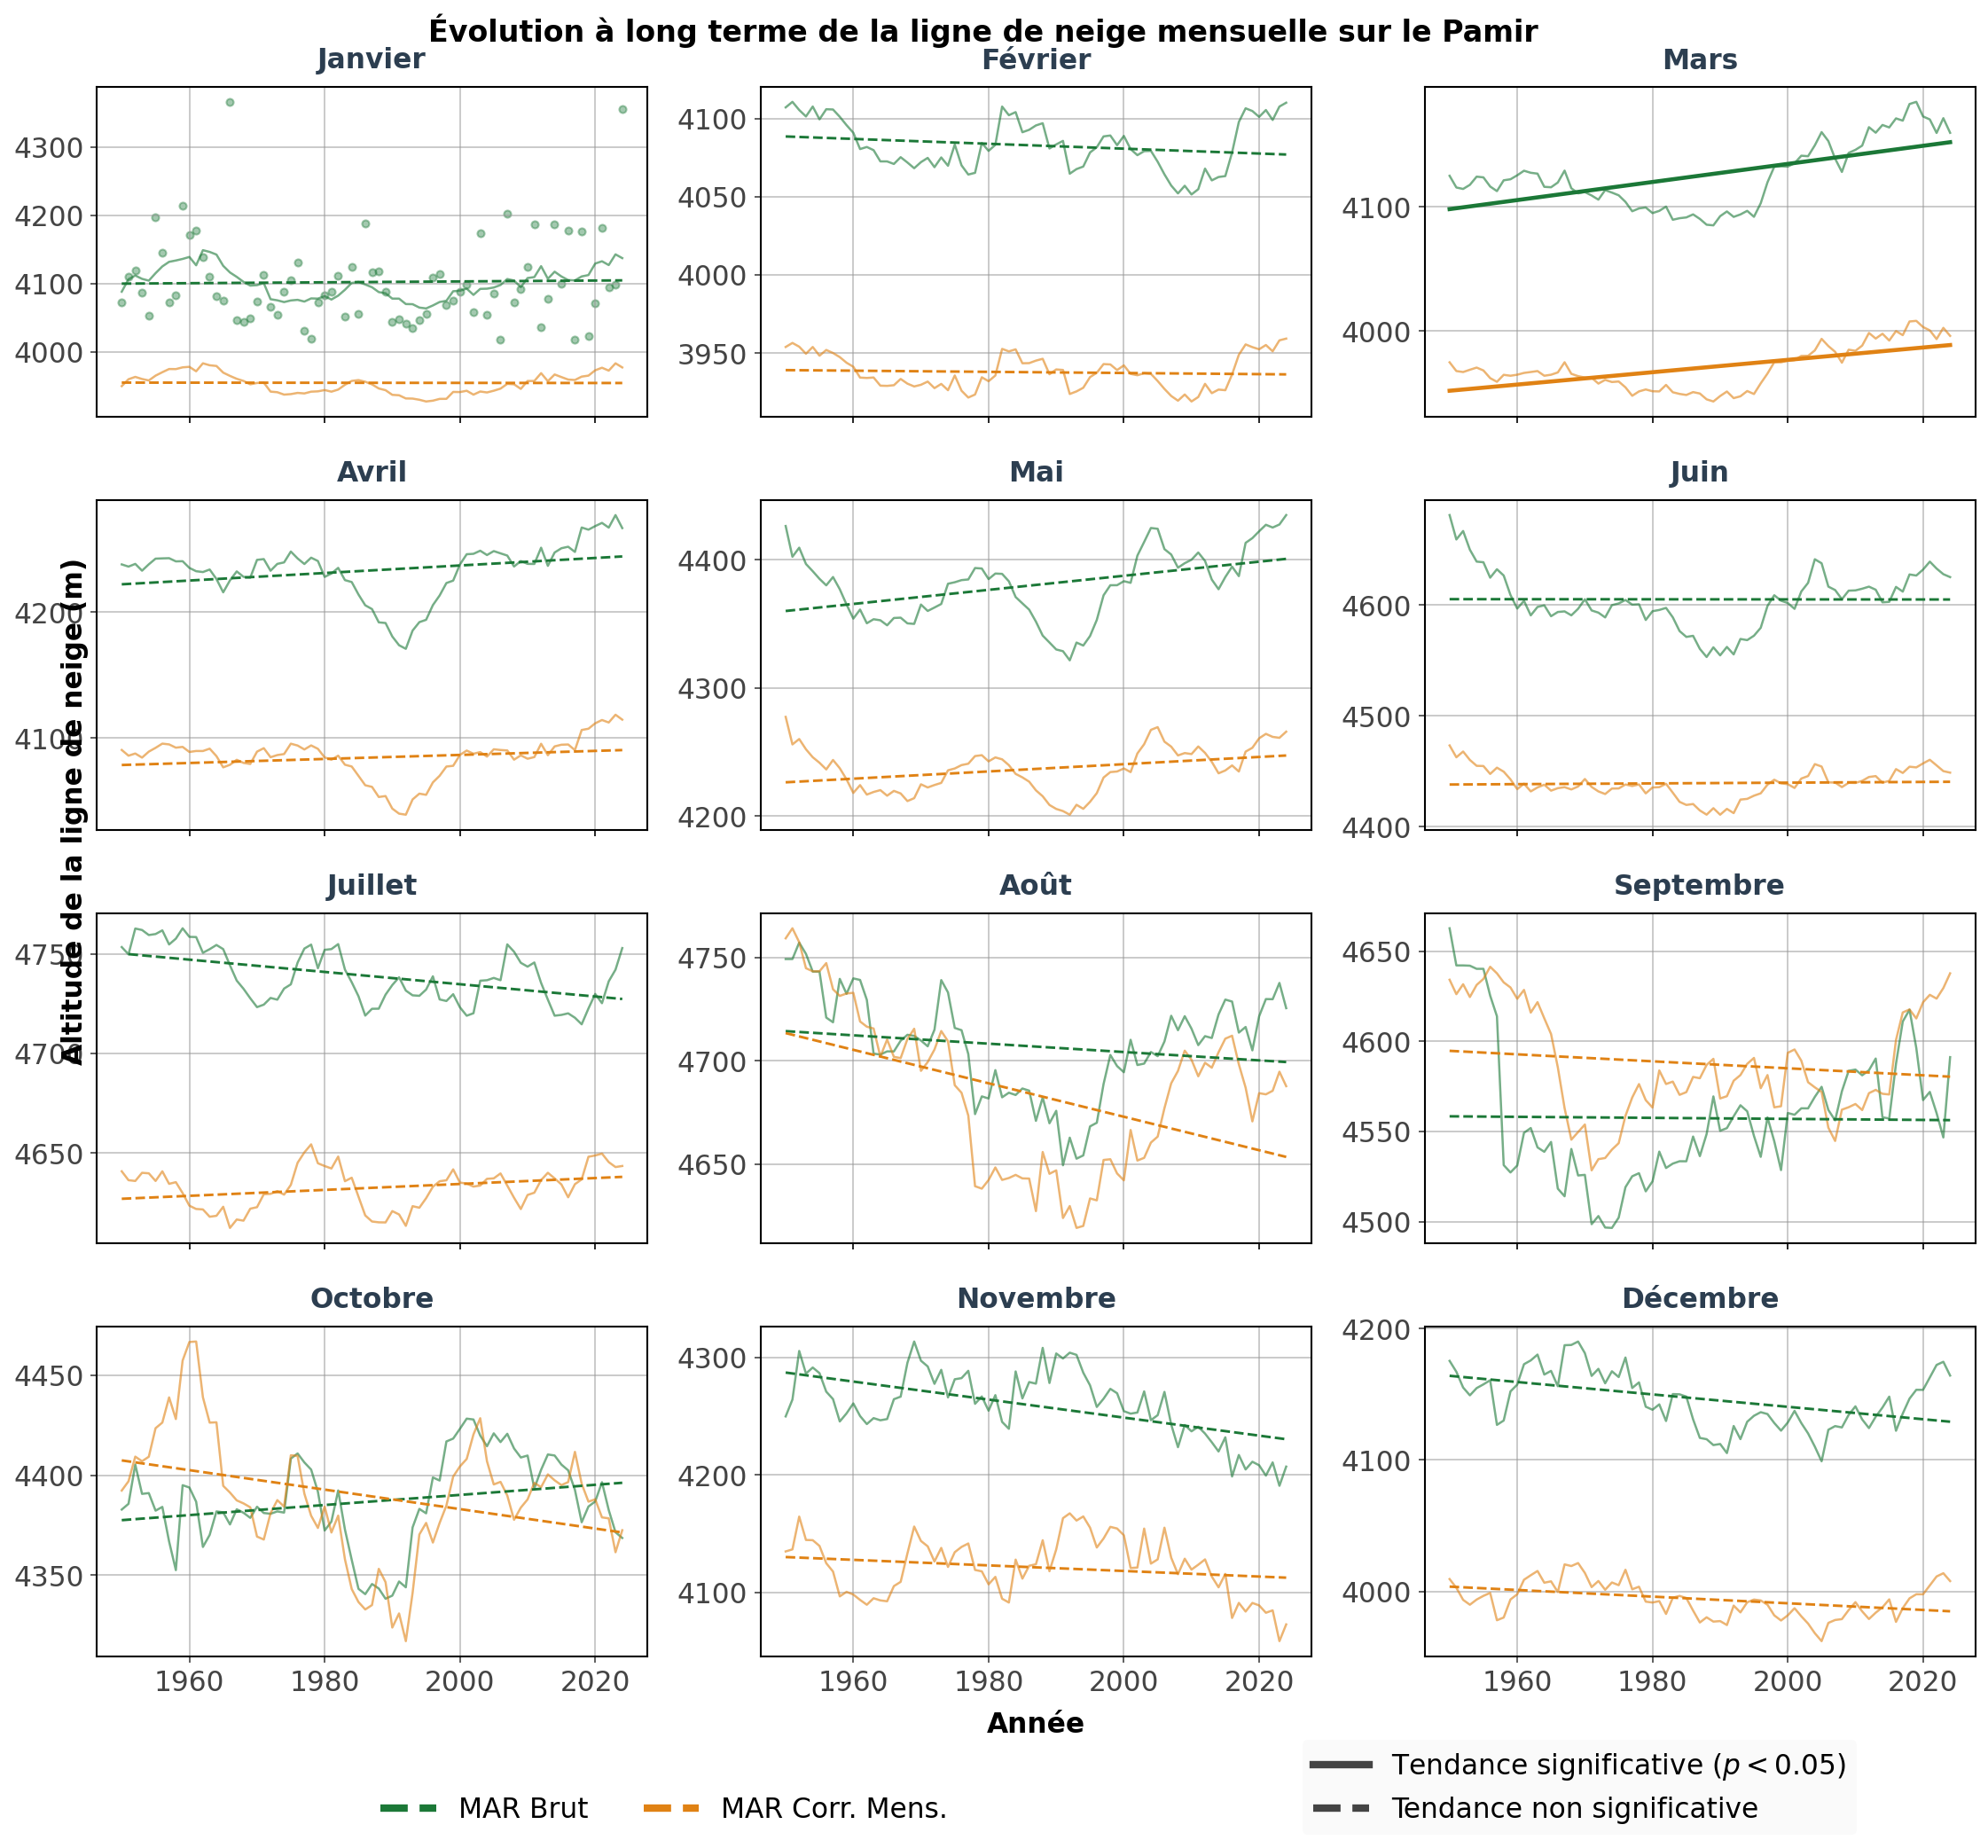

In [53]:
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Liberation Sans', 'Nimbus Sans', 'DejaVu Sans'],
    'font.size': 15,
    'axes.titlesize': 15,
    'axes.edgecolor': '#888888',
    'axes.linewidth': 1.0
})
mois_noms = ['Janvier', 'Février', 'Mars', 'Avril', 'Mai', 'Juin',
             'Juillet', 'Août', 'Septembre', 'Octobre', 'Novembre', 'Décembre']

fig, axs = plt.subplots(4, 3, figsize=(16, 15), sharey=False)
axs_flat = axs.flatten()

c_corr, c_brut = '#e08214', '#1b7837'

for i in range(months_per_year):
    ax = axs_flat[i]
    ax.set_title(mois_noms[i], color='#2c3e50', weight='bold', pad=10)
    lbl_brut = 'MAR Brut' if i == 0 else None
    lbl_corr = 'MAR Corr. Mens.' if i == 0 else None

    # --- BRUT ---
    roll_brut = pd.Series(monthly_ln_brut_pamir[:, i]).rolling(window=10, min_periods=3, center=True).mean()
    ax.plot(years_unique_pamir, roll_brut, color=c_brut, linewidth=1.2, alpha=0.6, zorder=2)

    if i == 0:
        ax.scatter(years_unique_pamir, monthly_ln_brut_pamir[:, i], color=c_brut, alpha=0.4, s=15, zorder=1)

    if not np.isnan(slope_brut_pamir[i]):
        sig = pvalue_brut_pamir[i] < 0.05
        style_l = 'solid' if sig else 'dashed'
        largeur_l = 2.2 if sig else 1.4
        mask = ~np.isnan(monthly_ln_brut_pamir[:, i])
        x_reg = np.where(mask)[0]
        intercept_local = np.nanmean(monthly_ln_brut_pamir[:, i]) - slope_brut_pamir[i] * np.mean(x_reg)
        ax.plot(years_unique_pamir[mask], intercept_local + slope_brut_pamir[i] * x_reg,
                color=c_brut, linestyle=style_l, linewidth=largeur_l, zorder=4, label=lbl_brut)

    # --- CORR ---
    roll_corr = pd.Series(monthly_ln_corr_pamir[:, i]).rolling(window=10, min_periods=3, center=True).mean()
    ax.plot(years_unique_pamir, roll_corr, color=c_corr, linewidth=1.2, alpha=0.6, zorder=2)

    if not np.isnan(slope_corr_pamir[i]):
        sig = pvalue_corr_pamir[i] < 0.05
        style_l = 'solid' if sig else 'dashed'
        largeur_l = 2.2 if sig else 1.4
        mask = ~np.isnan(monthly_ln_corr_pamir[:, i])
        x_reg = np.where(mask)[0]
        intercept_local = np.nanmean(monthly_ln_corr_pamir[:, i]) - slope_corr_pamir[i] * np.mean(x_reg)
        ax.plot(years_unique_pamir[mask], intercept_local + slope_corr_pamir[i] * x_reg,
                color=c_corr, linestyle=style_l, linewidth=largeur_l, zorder=4, label=lbl_corr)

    ax.grid(True, linestyle='--', alpha=0.3, color='#999999')
    ax.yaxis.set_tick_params(labelleft=True, labelsize=15, colors='#444444')

    if i >= 9:
        ax.xaxis.set_tick_params(labelbottom=True, labelsize=15, colors='#444444', rotation=0)
    else:
        ax.xaxis.set_tick_params(labelbottom=False)

    ax.grid(True, linestyle='-', alpha=0.6, color='#999999')
    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(True)     
        ax.spines[spine].set_color('black')    
        ax.spines[spine].set_linewidth(1.0)    

for ax in axs_flat[10:11]:
    ax.set_xlabel('Année', fontsize=15, fontweight='bold', labelpad=8)

leg1 = fig.legend(loc='lower center', bbox_to_anchor=(0.35, 0.01), ncol=2, frameon=False, fontsize=15)

legend_elements = [
    Line2D([0], [0], color='#444444', linestyle='-', linewidth=2, label='Tendance significative ($p < 0.05$)'),
    Line2D([0], [0], color='#444444', linestyle='--', linewidth=1.4, label='Tendance non significative')
]
leg2 = fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.78, 0.01), ncol=1,
                   frameon=True, facecolor='#f9f9f9', edgecolor='none', fontsize=15)
for line in leg1.get_lines():
    line.set_linewidth(4.0)
for line in leg2.get_lines():
    line.set_linewidth(4.0)

fig.text(0.073, 0.53, 'Altitude de la ligne de neige (m)', va='center', ha='center', rotation='vertical',
          fontsize=15, weight='bold')
plt.suptitle('Évolution à long terme de la ligne de neige mensuelle sur le Pamir', size=16, weight='bold', y=0.93)
plt.savefig('/home/mougina/mes_analyses_neige/comparaison_corrections_ligne_neige_pamir.png', dpi=200, bbox_inches='tight')
plt.tight_layout(rect=[0.03, 0.05, 0.98, 0.96])
plt.show()

## Au vu des resultats il peut etre interresant de voir la SCF mensuelle 

In [55]:
months_per_year = 12
years_unique_pamir = np.unique(scf_mensuel_brut_pamir.time.dt.year.values)
n_years_pamir = len(years_unique_pamir)

monthly_scf_brut_pamir = np.full((n_years_pamir, months_per_year), np.nan)
for iy, yr in enumerate(years_unique_pamir):
    for m in range(1, 13):
        vals = scf_mensuel_brut_pamir.sel(
            time=(scf_mensuel_brut_pamir.time.dt.year == yr) &
                 (scf_mensuel_brut_pamir.time.dt.month == m))
        if len(vals) > 0:
            monthly_scf_brut_pamir[iy, m-1] = float(vals.values)

monthly_scf_corr_pamir = np.full((n_years_pamir, months_per_year), np.nan)
for iy, yr in enumerate(years_unique_pamir):
    for m in range(1, 13):
        vals = scf_mensuel_corr_pamir.sel(
            time=(scf_mensuel_corr_pamir.time.dt.year == yr) &
                 (scf_mensuel_corr_pamir.time.dt.month == m))
        if len(vals) > 0:
            monthly_scf_corr_pamir[iy, m-1] = float(vals.values)

In [56]:
slope_scf_brut = np.full(months_per_year, np.nan); pvalue_scf_brut = np.full(months_per_year, np.nan)
slope_scf_corr = np.full(months_per_year, np.nan); pvalue_scf_corr = np.full(months_per_year, np.nan)

for imonth in range(months_per_year):
    mask_brut = ~np.isnan(monthly_scf_brut_pamir[:, imonth])
    if mask_brut.sum() > 10:
        reg_brut = stats.linregress(np.where(mask_brut)[0], monthly_scf_brut_pamir[mask_brut, imonth])
        slope_scf_brut[imonth], pvalue_scf_brut[imonth] = reg_brut.slope, reg_brut.pvalue

    mask_corr = ~np.isnan(monthly_scf_corr_pamir[:, imonth])
    if mask_corr.sum() > 10:
        reg_corr = stats.linregress(np.where(mask_corr)[0], monthly_scf_corr_pamir[mask_corr, imonth])
        slope_scf_corr[imonth], pvalue_scf_corr[imonth] = reg_corr.slope, reg_corr.pvalue

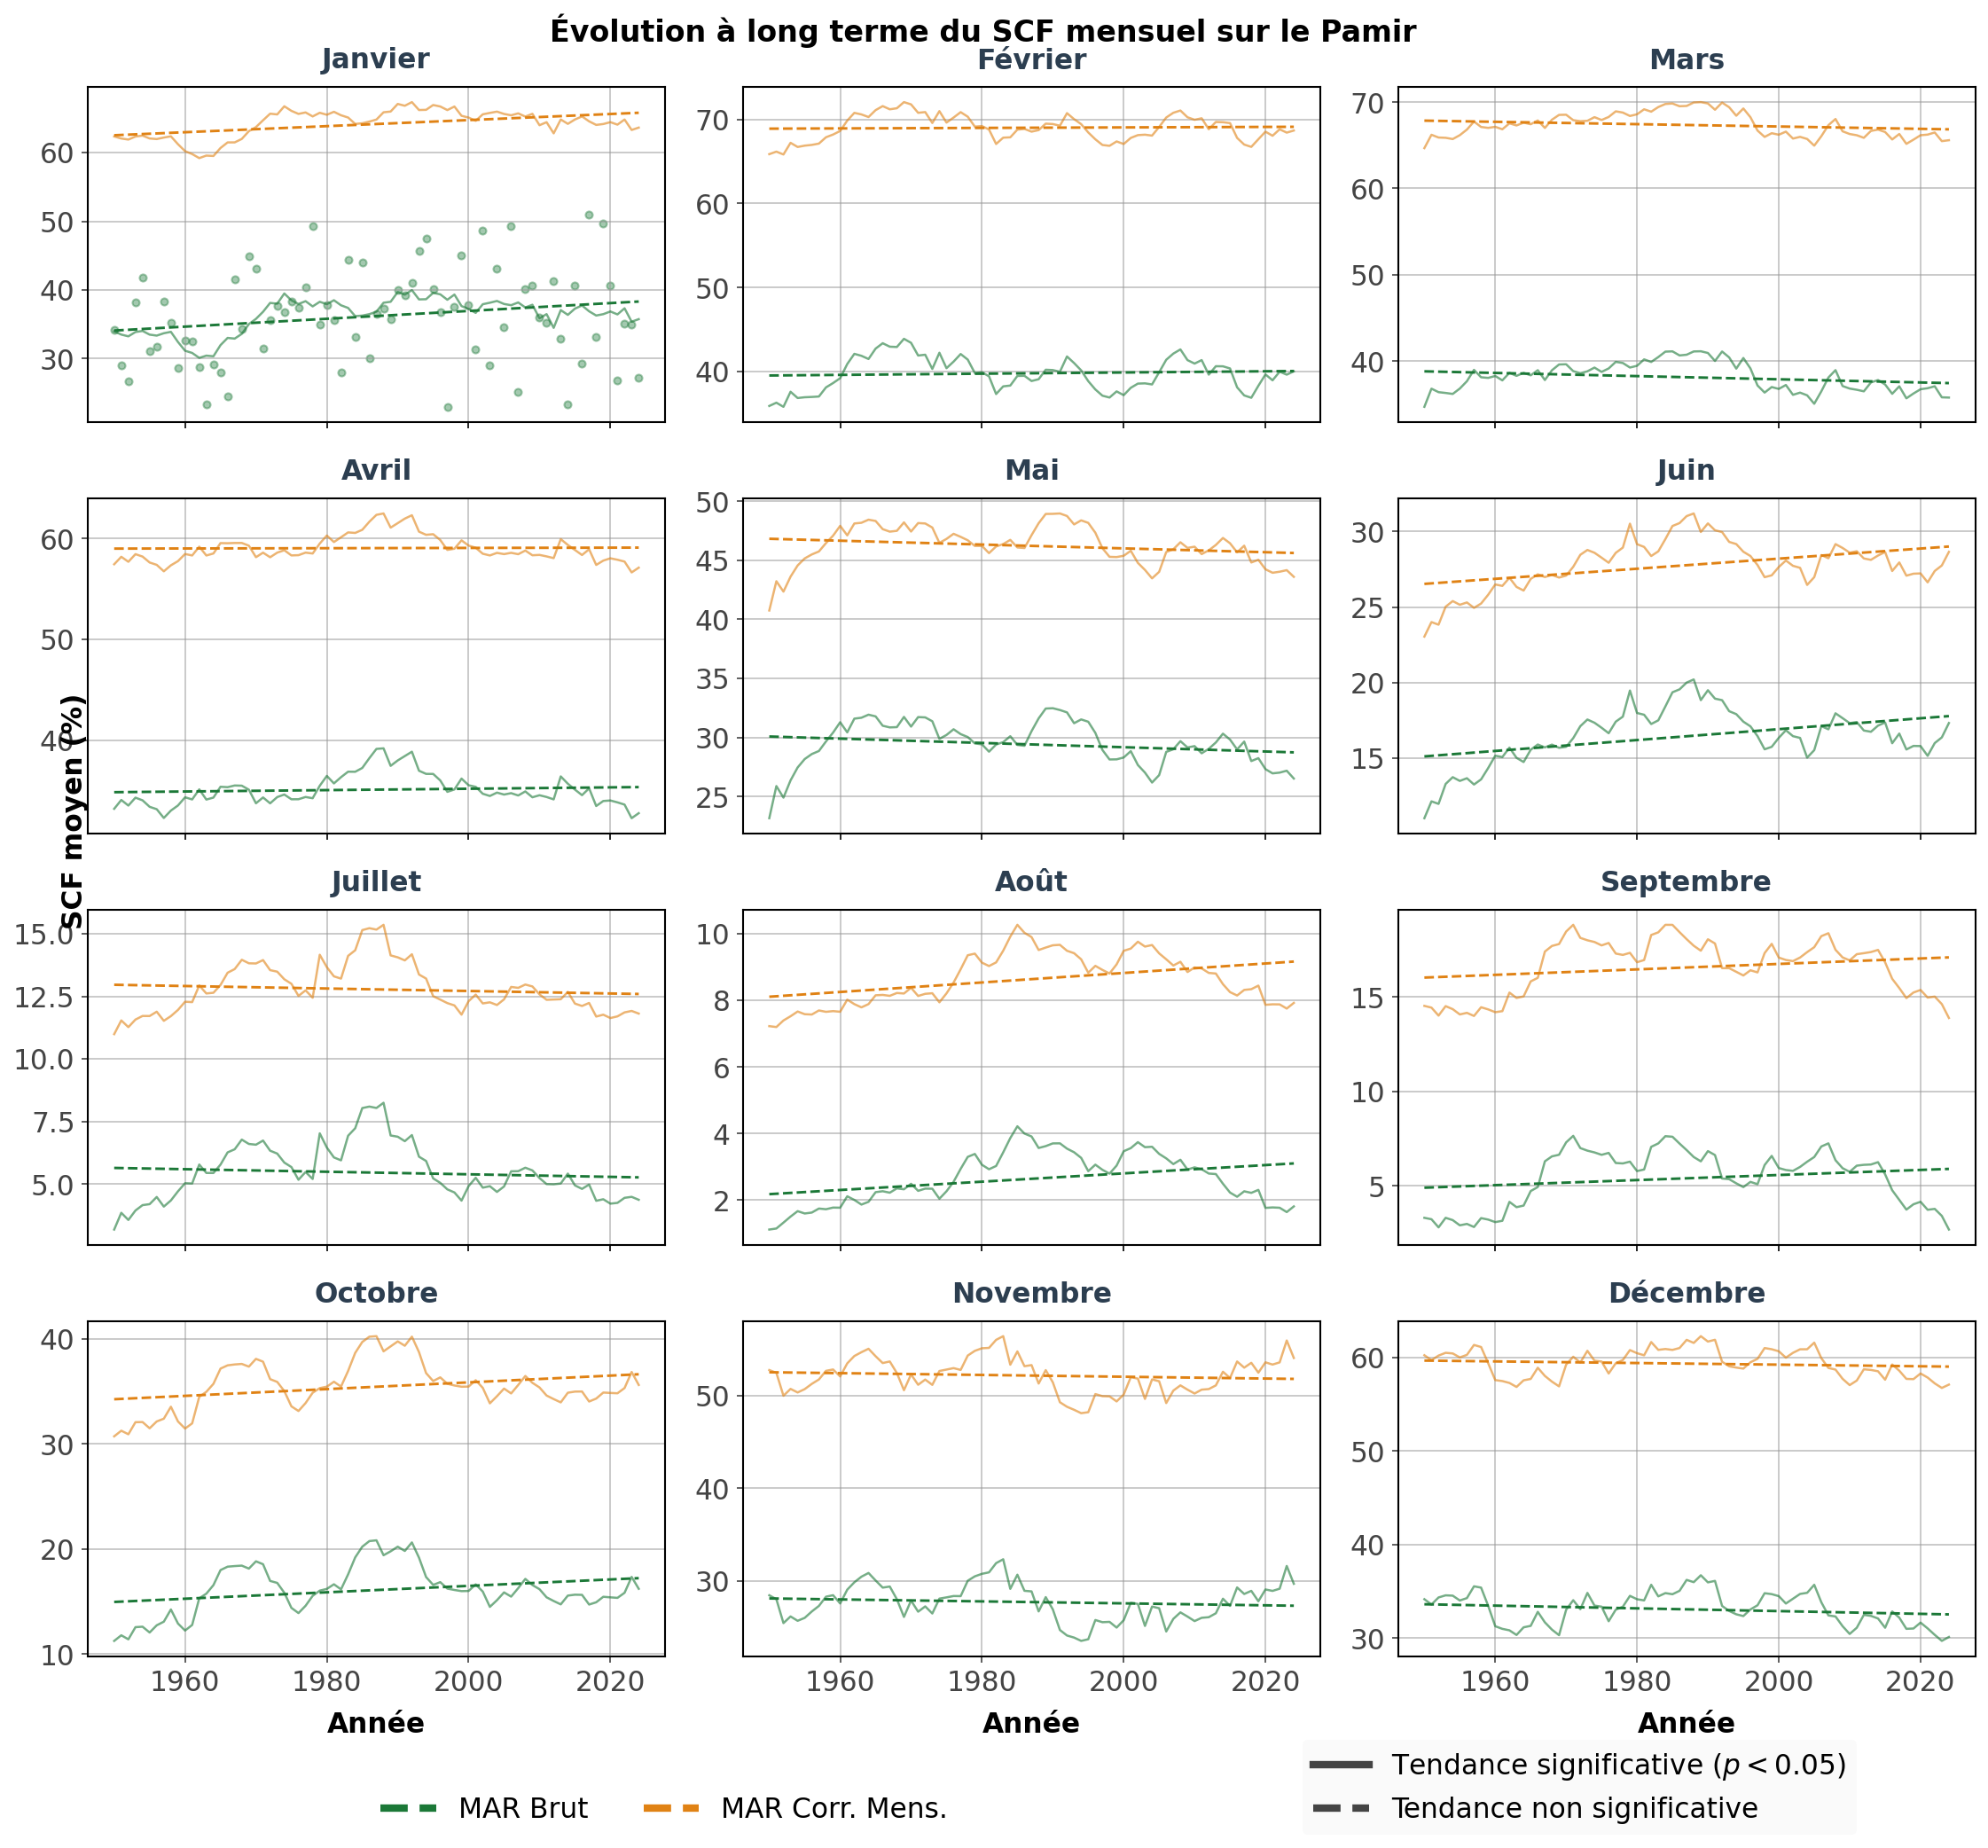

In [57]:
mois_noms = ['Janvier', 'Février', 'Mars', 'Avril', 'Mai', 'Juin',
             'Juillet', 'Août', 'Septembre', 'Octobre', 'Novembre', 'Décembre']

fig, axs = plt.subplots(4, 3, figsize=(16, 15), sharey=False)
axs_flat = axs.flatten()
c_corr, c_brut = '#e08214', '#1b7837'

for i in range(months_per_year):
    ax = axs_flat[i]
    ax.set_title(mois_noms[i], color='#2c3e50', weight='bold', pad=10)
    lbl_brut = 'MAR Brut' if i == 0 else None
    lbl_corr = 'MAR Corr. Mens.' if i == 0 else None

    roll_brut = pd.Series(monthly_scf_brut_pamir[:, i]).rolling(window=10, min_periods=3, center=True).mean()
    ax.plot(years_unique_pamir, roll_brut, color=c_brut, linewidth=1.2, alpha=0.6, zorder=2)
    if i == 0:
        ax.scatter(years_unique_pamir, monthly_scf_brut_pamir[:, i], color=c_brut, alpha=0.4, s=15, zorder=1)
    if not np.isnan(slope_scf_brut[i]):
        sig = pvalue_scf_brut[i] < 0.05
        style_l = 'solid' if sig else 'dashed'
        largeur_l = 2.2 if sig else 1.4
        mask = ~np.isnan(monthly_scf_brut_pamir[:, i])
        x_reg = np.where(mask)[0]
        intercept_local = np.nanmean(monthly_scf_brut_pamir[:, i]) - slope_scf_brut[i] * np.mean(x_reg)
        ax.plot(years_unique_pamir[mask], intercept_local + slope_scf_brut[i] * x_reg,
                color=c_brut, linestyle=style_l, linewidth=largeur_l, zorder=4, label=lbl_brut)

    roll_corr = pd.Series(monthly_scf_corr_pamir[:, i]).rolling(window=10, min_periods=3, center=True).mean()
    ax.plot(years_unique_pamir, roll_corr, color=c_corr, linewidth=1.2, alpha=0.6, zorder=2)
    if not np.isnan(slope_scf_corr[i]):
        sig = pvalue_scf_corr[i] < 0.05
        style_l = 'solid' if sig else 'dashed'
        largeur_l = 2.2 if sig else 1.4
        mask = ~np.isnan(monthly_scf_corr_pamir[:, i])
        x_reg = np.where(mask)[0]
        intercept_local = np.nanmean(monthly_scf_corr_pamir[:, i]) - slope_scf_corr[i] * np.mean(x_reg)
        ax.plot(years_unique_pamir[mask], intercept_local + slope_scf_corr[i] * x_reg,
                color=c_corr, linestyle=style_l, linewidth=largeur_l, zorder=4, label=lbl_corr)

    ax.grid(True, linestyle='--', alpha=0.3, color='#999999')
    ax.yaxis.set_tick_params(labelleft=True, labelsize=15, colors='#444444')
    if i >= 9:
        ax.xaxis.set_tick_params(labelbottom=True, labelsize=15, colors='#444444', rotation=0)
    else:
        ax.xaxis.set_tick_params(labelbottom=False)
    ax.grid(True, linestyle='-', alpha=0.6, color='#999999')
    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(True)     
        ax.spines[spine].set_color('black')    
        ax.spines[spine].set_linewidth(1.0)    

for ax in axs_flat[9:12]:
    ax.set_xlabel('Année', fontsize=15, fontweight='bold', labelpad=8)

leg1 = fig.legend(loc='lower center', bbox_to_anchor=(0.35, 0.01), ncol=2, frameon=False, fontsize=15)
legend_elements = [
    Line2D([0], [0], color='#444444', linestyle='-', linewidth=2, label='Tendance significative ($p < 0.05$)'),
    Line2D([0], [0], color='#444444', linestyle='--', linewidth=1.4, label='Tendance non significative')
]
leg2 = fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.78, 0.01), ncol=1,
                   frameon=True, facecolor='#f9f9f9', edgecolor='none', fontsize=15)
for line in leg1.get_lines():
    line.set_linewidth(4.0)
for line in leg2.get_lines():
    line.set_linewidth(4.0)

fig.text(0.073, 0.53, 'SCF moyen (%)', va='center', ha='center', rotation='vertical', fontsize=15, weight='bold')
plt.suptitle('Évolution à long terme du SCF mensuel sur le Pamir', size=16, weight='bold', y=0.93)
plt.savefig('/home/mougina/mes_analyses_neige/comparaison_corrections_scf_pamir.png', dpi=200, bbox_inches='tight')
plt.tight_layout(rect=[0.03, 0.05, 0.98, 0.96])
plt.show()

### FIN pour l'etude du PAMIR il peut etre utile d'aller chercher les corrections des Alpes QDM et de faire une etude similaire